In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [4]:
ne_lpn_model_config_path = os.path.join('..','models','ne_lpn','s=0.1','model_config.json')
ne_lpn_model_weight_path = os.path.join('..','models','ne_lpn','s=0.1','model.pt')
ne_lpn_model_config = load_config(ne_lpn_model_config_path)
ne_lpn_model = get_model(ne_lpn_model_config)
ne_lpn_model.load_state_dict(torch.load(ne_lpn_model_weight_path)['model_state_dict'])
ne_lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
    (5): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (6): Conv2d(64, 64, kernel_size=(16, 16), stride=(1, 1), bias=False, padding_mode=reflect)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
    (1): Conv2d(3, 64, kernel_siz

In [5]:
ne_lpn_by_forward_model_config_path = '../models/ne_by_forward_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forward_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [6]:
drunet_model_config_path = '../models/drunet/s=0.1/model_config.json'
drunet_model_weight_path = '../models/drunet/s=0.1/model.pt'
drunet_model_config = load_config(drunet_model_config_path)
drunet_model = get_model(drunet_model_config)
drunet_model.load_state_dict(torch.load(drunet_model_weight_path)['model_state_dict'])
drunet_model.to(device)

DRUNet(
  (m_head): AffineConv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
  (m_down): ModuleList(
    (0): Sequential(
      (0): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (1): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
          (1): SortPool()
          (2): AffineConv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, padding_mode=reflect)
        )
        (sum): ResidualConnection()
      )
      (2): ResBlock(
        (m_res): Sequential(
          (0): AffineConv2d(64, 64, 

In [7]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [8]:
noise_level = [0.05, 0.1, 0.3, 0.7]

In [9]:
ground_truths = []
noisy_images = []
ind = 0
for i, data in enumerate(test_dataloader):
    ground_truth = data['image'].to(device)
    noisy_image  = ground_truth + torch.randn_like(ground_truth) * noise_level[ind]
    ground_truths.append(ground_truth)
    noisy_images.append(noisy_image)
    ind += 1
    if ind >= len(noise_level):
        break

In [10]:
def test_model_on_images(model, clean_images, noise_levels):
    model.eval()
    output_images = []
    for i, noise_level in enumerate(noise_levels):
        img = clean_images[i]
        noise_tensor = torch.randn_like(img) * noise_level
        noisy_image = img + noise_tensor
        with torch.no_grad():
            output = model(noisy_image.unsqueeze(0))
        output_images.append(output.squeeze(0)) 
    return output_images


In [11]:
clean_images = [img.squeeze(0) for img in ground_truths] 

lpn_outputs = test_model_on_images(lpn_model, clean_images, noise_level)
ne_lpn_outputs = test_model_on_images(ne_lpn_model, clean_images, noise_level)
ne_lpn_by_forward_outputs = test_model_on_images(ne_lpn_by_forward_model, clean_images, noise_level)
drunet_outputs = test_model_on_images(drunet_model, clean_images, noise_level)

outputs = [lpn_outputs, ne_lpn_outputs, ne_lpn_by_forward_outputs, drunet_outputs]


In [12]:
print("shape of ground truths: ", ground_truths[0].shape)
print("shape of noisy images: ", noisy_images[0].shape)
print("shape of lpn outputs: ", lpn_outputs[0].shape)
print("shape of ne lpn outputs: ", ne_lpn_outputs[0].shape)
print("shape of ne lpn by forward outputs: ", ne_lpn_by_forward_outputs[0].shape)
print("shape of drunet outputs: ", drunet_outputs[0].shape)

shape of ground truths:  torch.Size([1, 3, 128, 128])
shape of noisy images:  torch.Size([1, 3, 128, 128])
shape of lpn outputs:  torch.Size([3, 128, 128])
shape of ne lpn outputs:  torch.Size([3, 128, 128])
shape of ne lpn by forward outputs:  torch.Size([3, 128, 128])
shape of drunet outputs:  torch.Size([3, 128, 128])


In [13]:
def plot_images_on_table(ground_truths, noisy_images, all_outputs, noise_levels, model_names):
    num_models = len(all_outputs)
    num_cols = 2 + num_models 
    fig, axs = plt.subplots(len(noise_levels), num_cols, figsize=(4 * num_cols, 4 * len(noise_levels)))

    for i, noise_level in enumerate(noise_levels):
        gt_img = ground_truths[i][0] if ground_truths[i].dim() == 4 else ground_truths[i]
        axs[i, 0].imshow(gt_img.permute(1, 2, 0).cpu().detach().numpy())
        if i == 0:
            axs[i, 0].set_title('Ground Truth')
        axs[i, 0].axis('off')

        for j in range(num_models):
            output_img = all_outputs[j][i]
            axs[i, j + 1].imshow(output_img.permute(1, 2, 0).cpu().detach().numpy())
            if i == 0:
                axs[i, j + 1].set_title(model_names[j])
            axs[i, j + 1].axis('off')

        noisy_img = noisy_images[i][0] if noisy_images[i].dim() == 4 else noisy_images[i]
        axs[i, num_cols - 1].imshow(noisy_img.permute(1, 2, 0).cpu().detach().numpy())
        if i == 0:
            axs[i, num_cols - 1].set_title(f"Noisy σ = {noise_level}")
        else:
            axs[i, num_cols - 1].set_title(f"σ = {noise_level}")
        axs[i, num_cols - 1].axis('off')

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

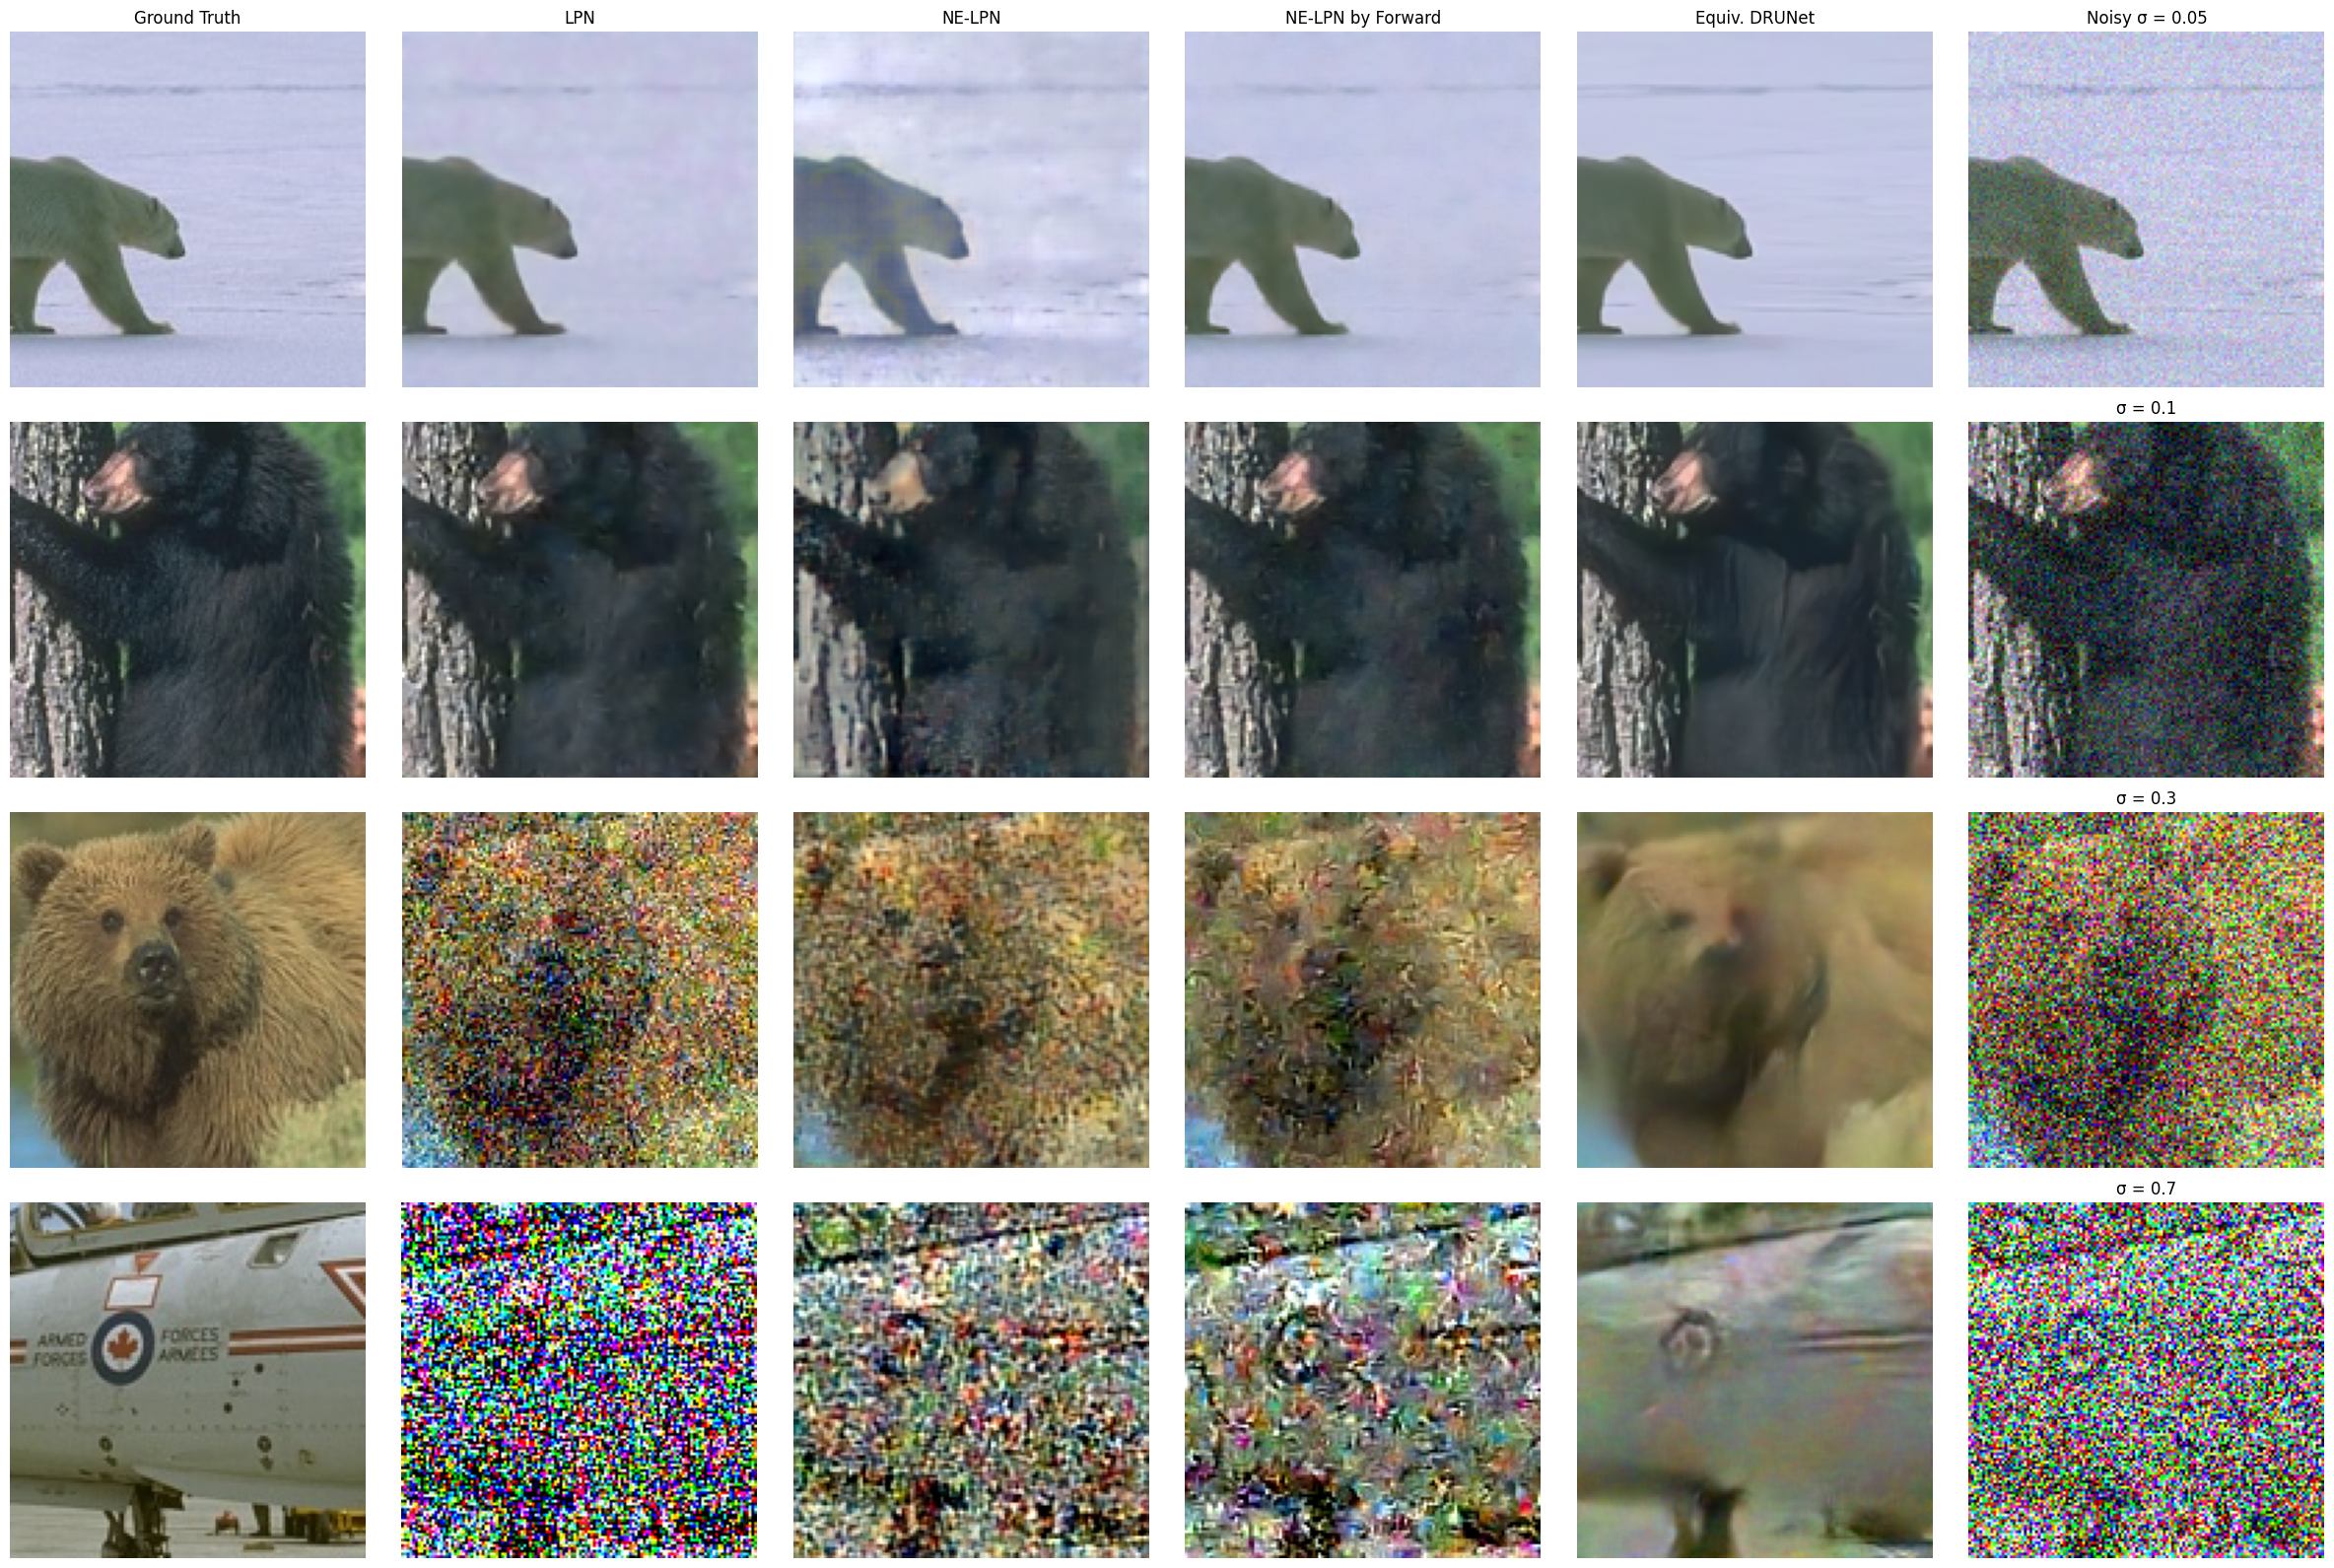

In [14]:
plot_images_on_table(ground_truths, noisy_images, outputs, noise_level, ['LPN', 'NE-LPN', 'NE-LPN by Forward', 'Equiv. DRUNet'])

#lets do something silly... lets feed in pure noise image and see what happens if we pass through model several times